<a href="https://colab.research.google.com/github/2211090028-debug/bhyT_cost_prediction/blob/main/bhyT_cost_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. IMPORT


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

In [4]:
#Load data
df = pd.read_csv("1651277648862_healthinsurance.csv")

print("Kích thước dữ liệu:", df.shape)
print(df.info())

Kích thước dữ liệu: (15000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB
None


In [5]:
# Xử lý missing values
df['age'] = df['age'].fillna(df['age'].median())
df['bmi']  = df['bmi'].fillna(df['bmi'].median())

2. EDA

In [6]:
print("\n=== THỐNG KÊ MÔ TẢ ===")
print(df.describe())


=== THỐNG KÊ MÔ TẢ ===
                age        weight           bmi  no_of_dependents  \
count  15000.000000  15000.000000  15000.000000      15000.000000   
mean      39.559467     64.909600     30.211193          1.129733   
std       13.829896     13.701935      5.928386          1.228469   
min       18.000000     34.000000     16.000000          0.000000   
25%       27.000000     54.000000     25.900000          0.000000   
50%       40.000000     63.000000     29.400000          1.000000   
75%       51.000000     76.000000     34.100000          2.000000   
max       64.000000     95.000000     53.100000          5.000000   

             smoker  bloodpressure      diabetes    regular_ex         claim  
count  15000.000000   15000.000000  15000.000000  15000.000000  15000.000000  
mean       0.198133      68.650133      0.777000      0.224133  13401.437620  
std        0.398606      19.418515      0.416272      0.417024  12148.239619  
min        0.000000       0.000000    

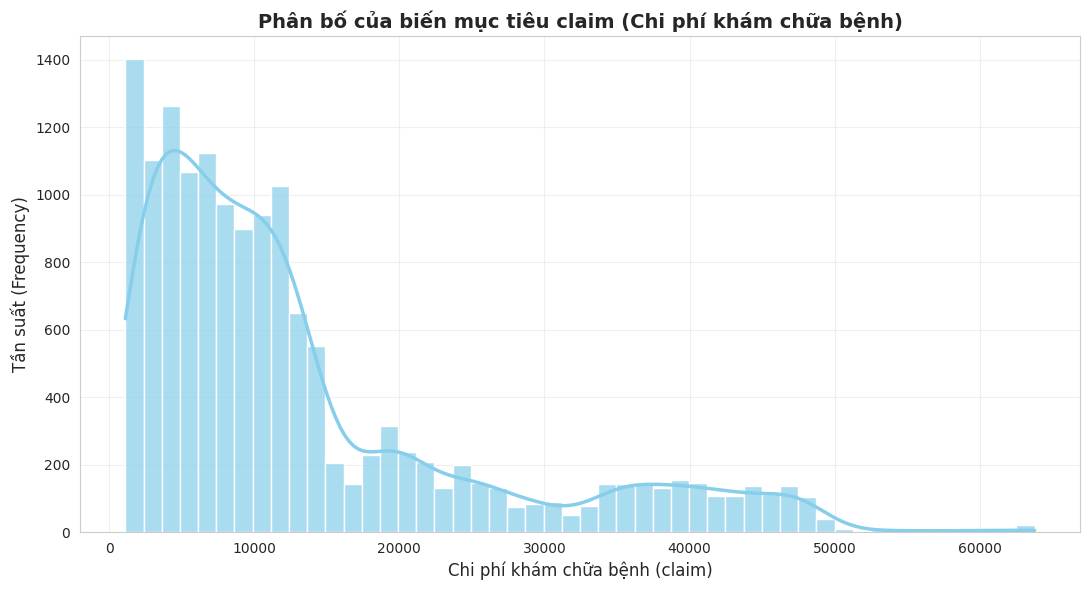

In [7]:
# PHÂN BỐ CỦA BIẾN MỤC TIÊU CLAIM
plt.figure(figsize=(11, 6))

sns.histplot(df['claim'],
             kde=True,
             bins=50,
             color='skyblue',
             alpha=0.7,
             line_kws={'color': 'red', 'linewidth': 2.5})

plt.title("Phân bố của biến mục tiêu claim (Chi phí khám chữa bệnh)", fontsize=14, fontweight='bold')
plt.xlabel("Chi phí khám chữa bệnh (claim)", fontsize=12)
plt.ylabel("Tần suất (Frequency)", fontsize=12)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

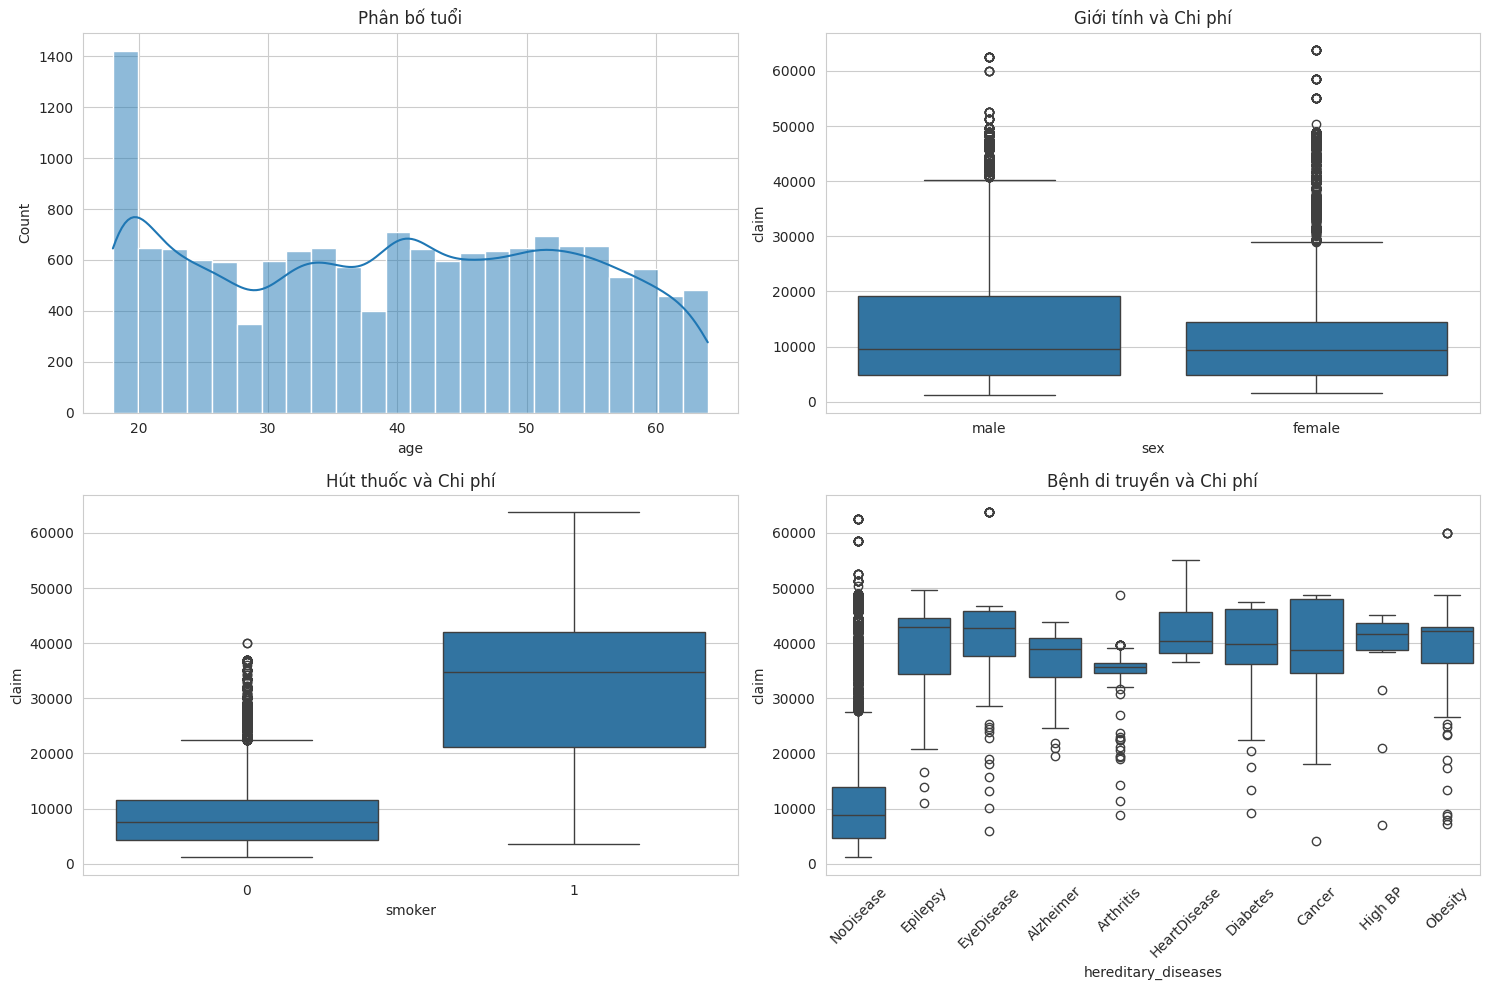

In [8]:
# Nhóm 1: Đặc điểm người bệnh (Demographics & Health Status)
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.histplot(df['age'], kde=True)
plt.title("Phân bố tuổi")

plt.subplot(2,2,2)
sns.boxplot(x='sex', y='claim', data=df)
plt.title("Giới tính và Chi phí")

plt.subplot(2,2,3)
sns.boxplot(x='smoker', y='claim', data=df)
plt.title("Hút thuốc và Chi phí")

plt.subplot(2,2,4)
sns.boxplot(x='hereditary_diseases', y='claim', data=df)
plt.xticks(rotation=45)
plt.title("Bệnh di truyền và Chi phí")
plt.tight_layout()
plt.show()

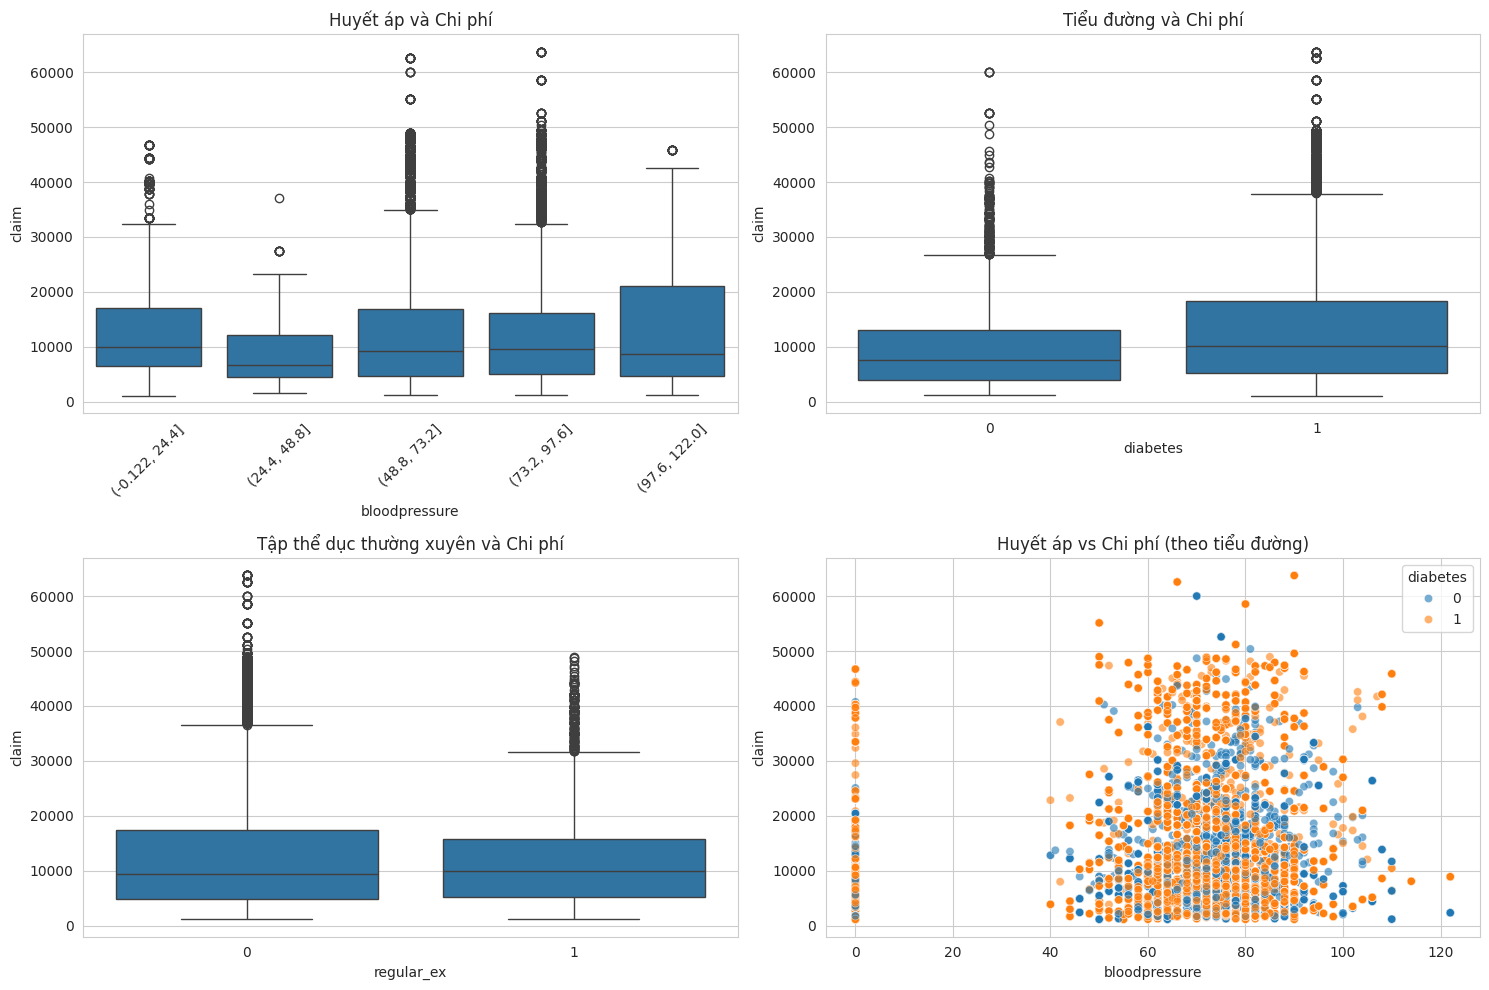

In [9]:
# Nhóm 2 Yếu tố lâm sàng
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x=pd.cut(df['bloodpressure'], bins=5), y='claim', data=df)
plt.xticks(rotation=45)
plt.title("Huyết áp và Chi phí")

plt.subplot(2, 2, 2)
sns.boxplot(x='diabetes', y='claim', data=df)
plt.title("Tiểu đường và Chi phí")

plt.subplot(2, 2, 3)
sns.boxplot(x='regular_ex', y='claim', data=df)
plt.title("Tập thể dục thường xuyên và Chi phí")

plt.subplot(2, 2, 4)
sns.scatterplot(x='bloodpressure', y='claim', hue='diabetes', data=df, alpha=0.6)
plt.title("Huyết áp vs Chi phí (theo tiểu đường)")
plt.tight_layout()
plt.show()

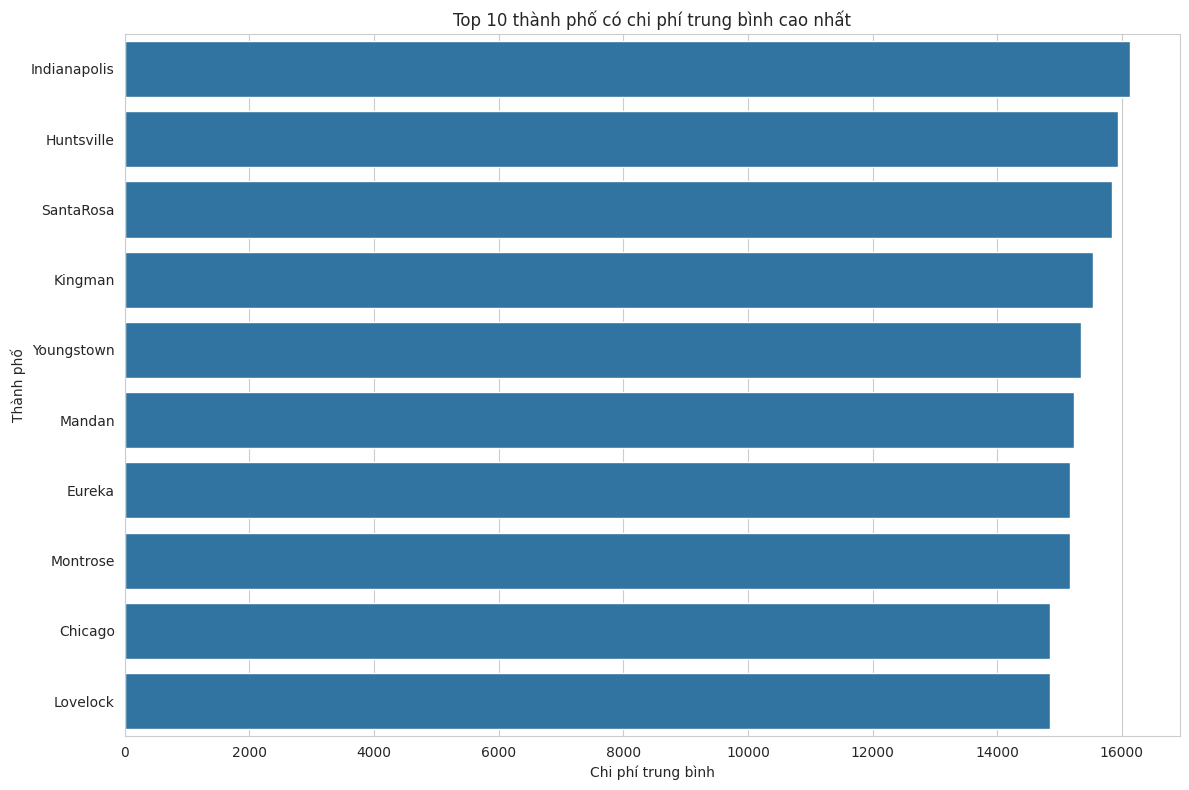

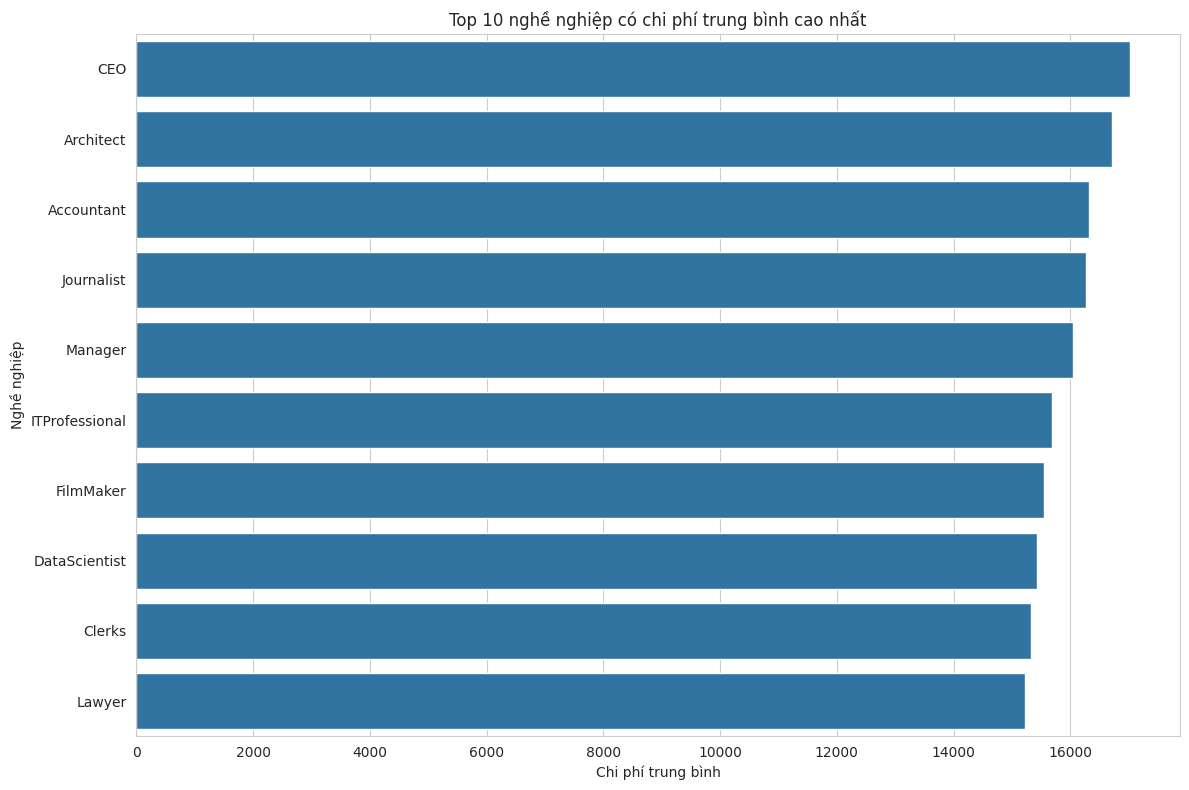

In [10]:
# Nhóm 3 Yếu tố hệ thống, chính sách
top_cities = df.groupby('city')['claim'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_cities.values, y=top_cities.index, orient='h')
plt.title("Top 10 thành phố có chi phí trung bình cao nhất")
plt.xlabel("Chi phí trung bình")
plt.ylabel("Thành phố")
plt.tight_layout()
plt.show()

top_jobs = df.groupby('job_title')['claim'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_jobs.values, y=top_jobs.index, orient='h')
plt.title("Top 10 nghề nghiệp có chi phí trung bình cao nhất")
plt.xlabel("Chi phí trung bình")
plt.ylabel("Nghề nghiệp")
plt.tight_layout()
plt.show()

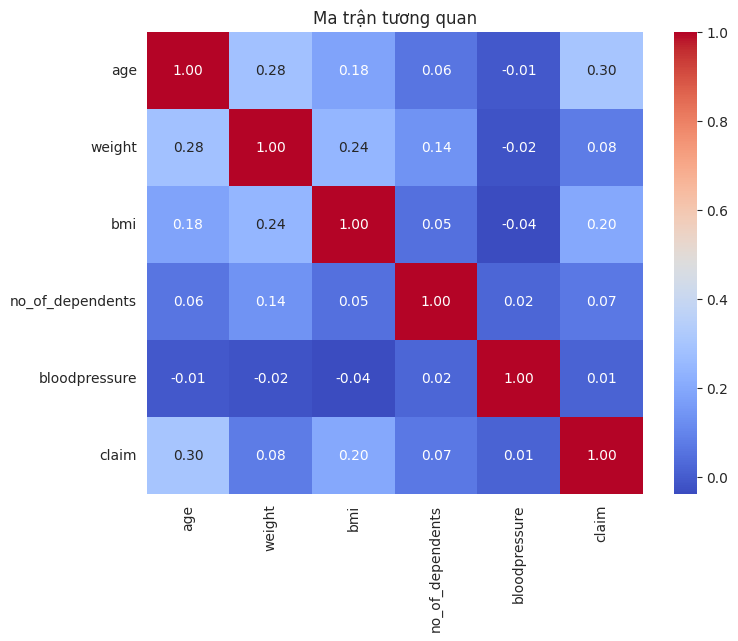

In [11]:
# Correlation
numeric_cols = ['age','weight','bmi','no_of_dependents','bloodpressure','claim']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Ma trận tương quan")
plt.show()

3. PREPROCESSING

In [12]:
X = df.drop('claim', axis=1)
y = df['claim']

cat_cols = ['sex', 'hereditary_diseases', 'city', 'job_title']
num_cols = ['age', 'weight', 'bmi', 'no_of_dependents',
            'bloodpressure', 'diabetes', 'regular_ex', 'smoker']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. XÂY DỰNG MÔ HÌNH

In [13]:
# 1. Linear Regression
lr_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

In [14]:
# 2. Random Forest
rf_pipe = Pipeline([('prep', preprocessor),
                    ('model', RandomForestRegressor(n_estimators=300, random_state=42))])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

In [15]:
# 3. XGBoost
xgb_pipe = Pipeline([('prep', preprocessor),
                     ('model', XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42))])
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

In [16]:
# 4. Neural Network (Log Transform)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

def build_dl_model(input_dim):
    model = Sequential([
        Dense(512, input_dim=input_dim),
        BatchNormalization(), LeakyReLU(0.1), Dropout(0.3),
        Dense(256), BatchNormalization(), LeakyReLU(0.1), Dropout(0.3),
        Dense(128), BatchNormalization(), LeakyReLU(0.1), Dropout(0.2),
        Dense(64),  BatchNormalization(), LeakyReLU(0.1), Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

dl_model = build_dl_model(X_train_prep.shape[1])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

dl_model.fit(X_train_prep, y_train_log, epochs=200, batch_size=64,
             validation_split=0.2, callbacks=callbacks, verbose=1)

y_pred_dl_log = dl_model.predict(X_test_prep, verbose=0).flatten()
y_pred_dl = np.expm1(y_pred_dl_log)

Epoch 1/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 37.9183 - mae: 5.8900 - val_loss: 31.5331 - val_mae: 5.5709 - learning_rate: 0.0010
Epoch 2/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.3507 - mae: 1.9095 - val_loss: 5.4221 - val_mae: 2.2472 - learning_rate: 0.0010
Epoch 3/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9321 - mae: 1.1092 - val_loss: 1.0086 - val_mae: 0.8849 - learning_rate: 0.0010
Epoch 4/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.7021 - mae: 1.0337 - val_loss: 0.2974 - val_mae: 0.3850 - learning_rate: 0.0010
Epoch 5/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5960 - mae: 0.9976 - val_loss: 0.2451 - val_mae: 0.3502 - learning_rate: 0.0010
Epoch 6/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5112 - mae: 0.9759 - val_loss: 0.1902 - val_mae: 0.2990 - learning_rate: 0.0010
Epoch 7/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1.4024 - mae: 0.9331 - val_loss: 0.2189 - val_mae: 0.3477 - learning_rate: 0.

In [17]:
# HYPERPARAMETER TUNING XGBOOST
from sklearn.model_selection import GridSearchCV

xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [200, 300, 400],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [5, 6, 7],
    'model__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    xgb_pipe,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score (RMSE):", np.sqrt(-grid_search.best_score_))

best_xgb = grid_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best score (RMSE): 2345.3464856159085


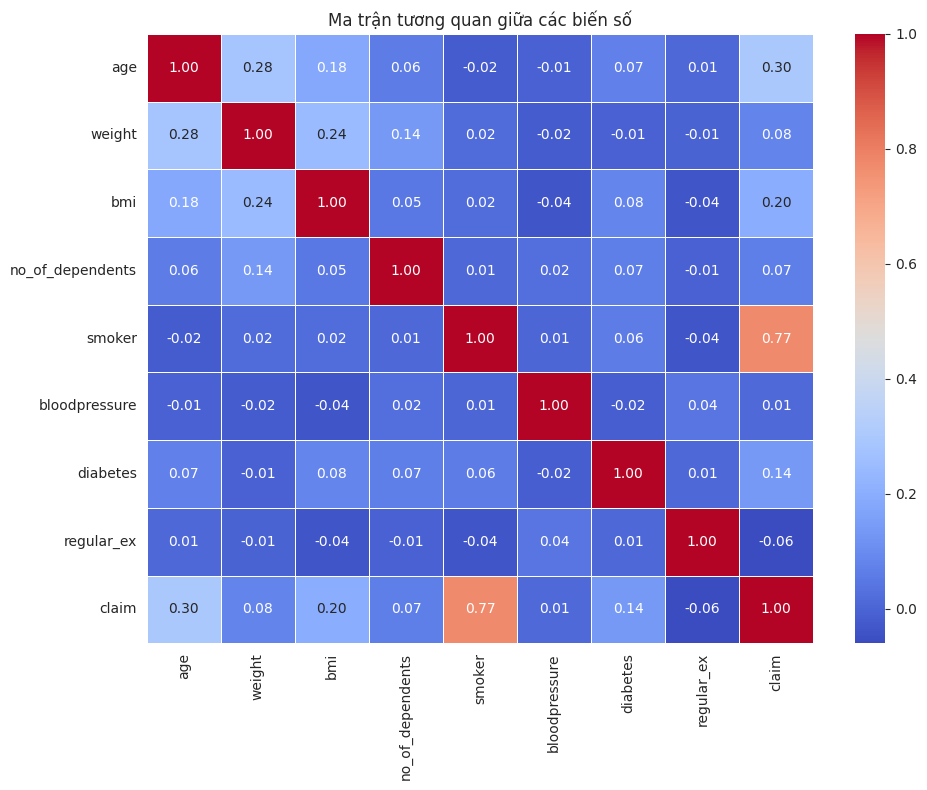

Smoker → F-statistic: 22323.96, p-value: 0.00000 (có ý nghĩa)
Diabetes → F-statistic: 279.97, p-value: 0.00000 (có ý nghĩa)
Hereditary diseases → F-statistic: 822.36, p-value: 0.00000 (có ý nghĩa)


In [18]:
# CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

# ANOVA Test cho một số biến quan trọng
from scipy import stats

# ANOVA smoker
f_stat, p_value = stats.f_oneway(
    df[df['smoker'] == 0]['claim'],
    df[df['smoker'] == 1]['claim']
)
print(f"Smoker → F-statistic: {f_stat:.2f}, p-value: {p_value:.5f} {'(có ý nghĩa)' if p_value < 0.05 else ''}")

# ANOVA diabetes
f_stat, p_value = stats.f_oneway(
    df[df['diabetes'] == 0]['claim'],
    df[df['diabetes'] == 1]['claim']
)
print(f"Diabetes → F-statistic: {f_stat:.2f}, p-value: {p_value:.5f} {'(có ý nghĩa)' if p_value < 0.05 else ''}")

# ANOVA hereditary_diseases
groups = [df[df['hereditary_diseases'] == cat]['claim'] for cat in df['hereditary_diseases'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Hereditary diseases → F-statistic: {f_stat:.2f}, p-value: {p_value:.5f} {'(có ý nghĩa)' if p_value < 0.05 else ''}")

5. ĐÁNH GIÁ & SO SÁNH

In [19]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "Neural Network"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_dl)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_dl))
    ],
    "R²": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_dl)
    ]
})

print("=== KẾT QUẢ SO SÁNH MÔ HÌNH ===")
print(results.round(4).sort_values(by="R²", ascending=False))

=== KẾT QUẢ SO SÁNH MÔ HÌNH ===
               Model        MAE       RMSE      R²
1      Random Forest   552.7079  2304.5107  0.9644
2            XGBoost  1409.2807  2807.5040  0.9472
3     Neural Network  2285.6961  4299.4056  0.8762
0  Linear Regression  3914.9670  5989.9699  0.7598


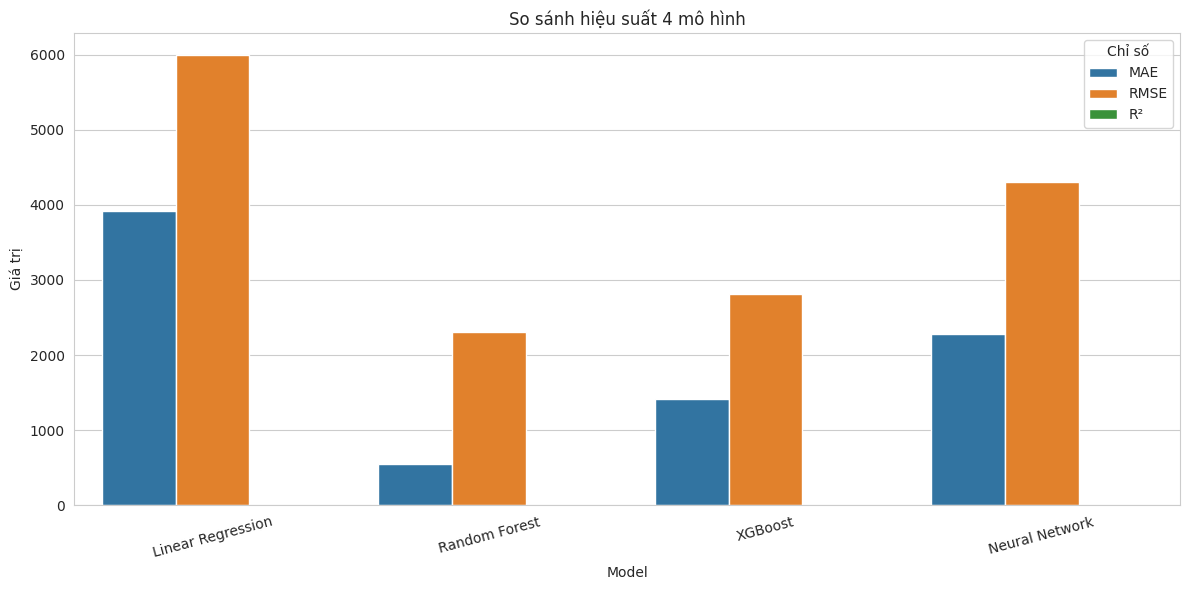

In [20]:
# Biểu đồ cột so sánh
results_melt = results.melt(id_vars="Model", var_name="Metric", value_name="Value")
plt.figure(figsize=(12,6))
sns.barplot(data=results_melt, x="Model", y="Value", hue="Metric")
plt.title("So sánh hiệu suất 4 mô hình")
plt.ylabel("Giá trị")
plt.xticks(rotation=15)
plt.legend(title="Chỉ số")
plt.tight_layout()
plt.show()

6. VISUALIZATION

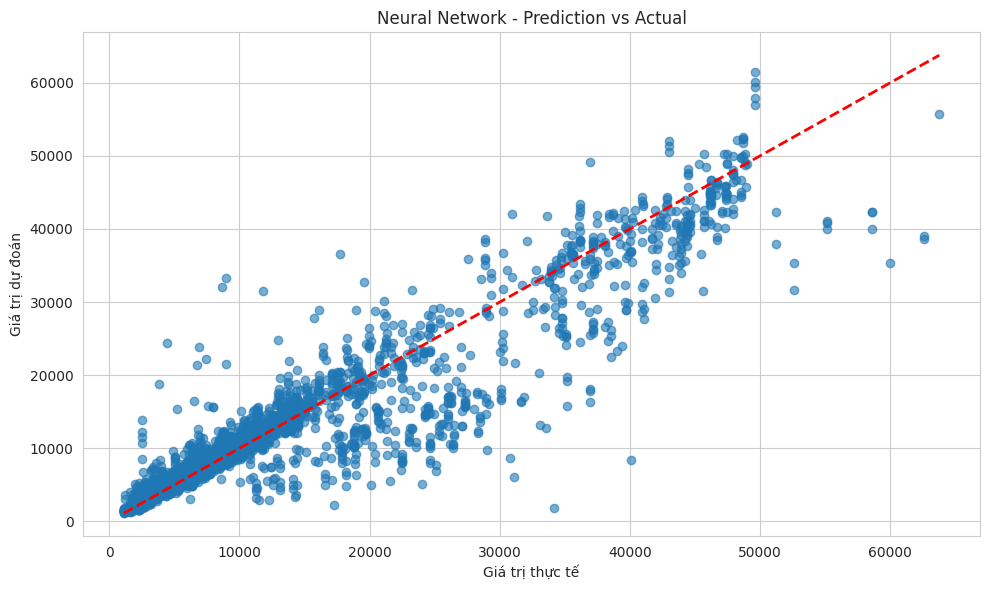

In [21]:
# Prediction vs Actual
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_dl, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title("Neural Network - Prediction vs Actual")
plt.tight_layout()
plt.show()

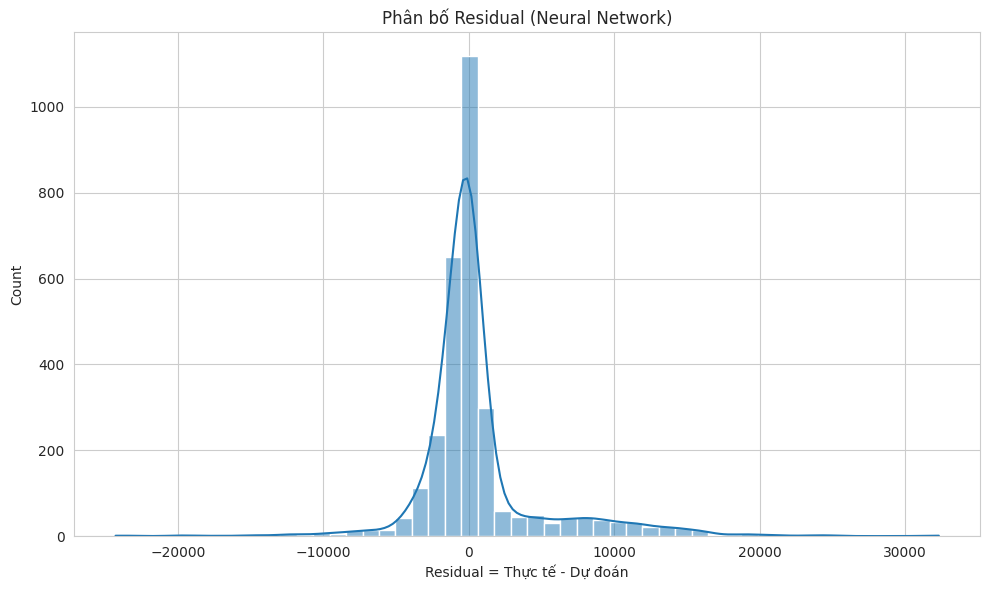

In [22]:
# Residual Plot (Neural Network)
residuals = y_test - y_pred_dl
plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, bins=50)
plt.title("Phân bố Residual (Neural Network)")
plt.xlabel("Residual = Thực tế - Dự đoán")
plt.tight_layout()
plt.show()

7. FEATURE IMPORTANCE

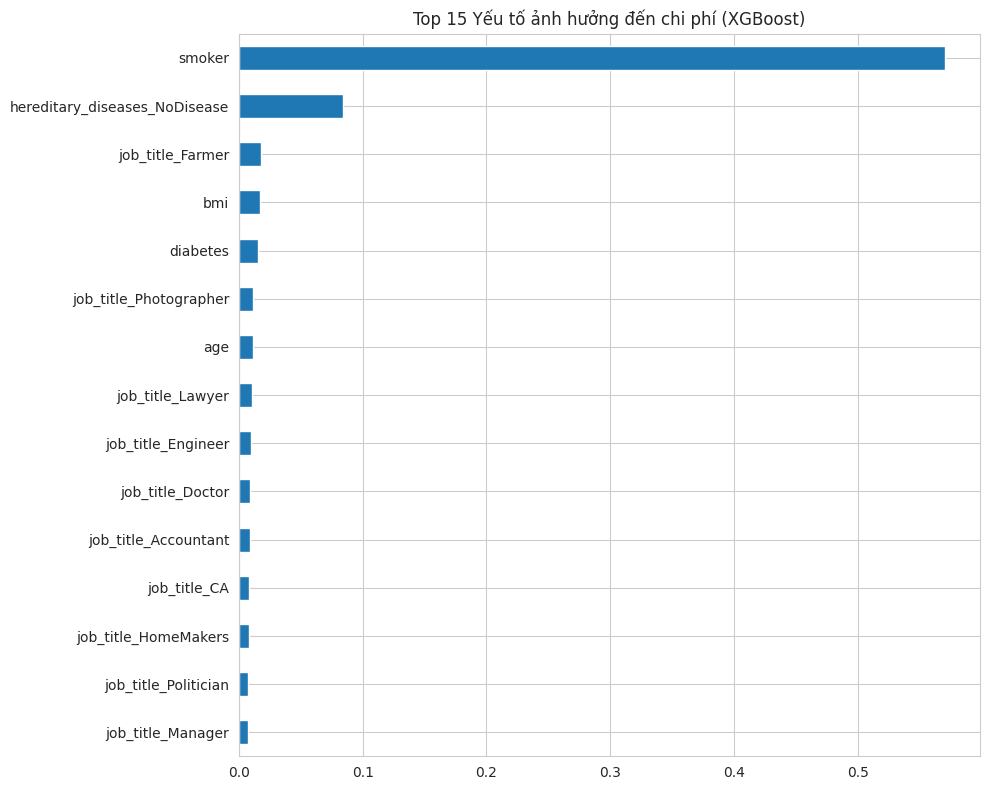


Top 10 yếu tố quan trọng nhất:
smoker                           0.570381
hereditary_diseases_NoDisease    0.084263
job_title_Farmer                 0.017616
bmi                              0.017313
diabetes                         0.015285
job_title_Photographer           0.011443
age                              0.011430
job_title_Lawyer                 0.010444
job_title_Engineer               0.009845
job_title_Doctor                 0.009226
dtype: float32


In [23]:
feature_names = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
feat_imp = pd.Series(best_xgb.named_steps['model'].feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,8))
feat_imp.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Yếu tố ảnh hưởng đến chi phí (XGBoost)")
plt.tight_layout()
plt.show()

print("\nTop 10 yếu tố quan trọng nhất:")
print(feat_imp.head(10))